## 1. Install Dependencies


In [1]:
import sys
!{sys.executable} -m pip install tensorflow librosa==0.11.0 scikit-learn tqdm numpy pandas matplotlib seaborn --quiet



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and Setup


In [52]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report, f1_score
)

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    Flatten, Dense, Dropout, GlobalAveragePooling2D
)
from keras.optimizers import Adam
from keras.losses import SparseCategoricalCrossentropy
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

SR      = 22050
N_MELS  = 128
N_FFT   = 2048
HOP_LEN = 512
FMIN    = 20
FMAX    = 8000

N_FRAMES   = 128
HOP_FRAMES = 64
N_CLASSES  = 10
BATCH_SIZE = 32
EPOCHS     = 100

CLASSES = [
    'bus', 'busystreet', 'office', 'openairmarket', 'park',
    'quietstreet', 'restaurant', 'supermarket', 'tube', 'tubestation'
]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}

OUTPUT_DIR = 'output_block1'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('TensorFlow version:', tf.__version__)
print('Devices available :', tf.config.list_physical_devices())
print(f'CNN input shape per segment: ({N_FRAMES}, {N_MELS}, 1)')
print(f'Segment duration: {N_FRAMES * HOP_LEN / SR:.2f}s')
print(f'Overlap: {HOP_FRAMES * HOP_LEN / SR:.2f}s')


TensorFlow version: 2.21.0
Devices available : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
CNN input shape per segment: (128, 128, 1)
Segment duration: 2.97s
Overlap: 1.49s


## 3. Load Annotations from Block 1




In [53]:
df_train = pd.read_csv(os.path.join(OUTPUT_DIR, 'dcase2013_annotations.csv'))
print(f'Train files: {len(df_train)}')
print(df_train['label'].value_counts().sort_index())


Train files: 100
label
bus              10
busystreet       10
office           10
openairmarket    10
park             10
quietstreet      10
restaurant       10
supermarket      10
tube             10
tubestation      10
Name: count, dtype: int64


## 4. Spectrogram Extraction and Segmentation




In [ ]:
def preprocess_audio(filepath, sr=SR):
    wav, _ = librosa.load(filepath, sr=sr, mono=True)
    wav = wav / (np.max(np.abs(wav)) + 1e-9)
    return wav


def extract_logmel_spectrogram(wav, sr=SR):
    """
    Extrae el espectrograma Log-Mel completo.
    Returns shape: (T_frames, N_MELS) — primer tiempo para facilitar el slicing.
    """
    mel = librosa.feature.melspectrogram(
        y=wav, sr=sr, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LEN,
        fmin=FMIN, fmax=FMAX
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return log_mel.T  # (T, N_MELS)


def segment_spectrogram(spec, n_frames=N_FRAMES, hop_frames=HOP_FRAMES):
    """
    Divide un espectrograma en segmentos solapados de longitud fija.
    Returns shape: (N_segments, n_frames, N_MELS)
    """
    segments = []
    T = spec.shape[0]
    for start in range(0, T - n_frames + 1, hop_frames):
        segments.append(spec[start : start + n_frames])
    return np.array(segments)


# Test rápido
test_wav  = preprocess_audio(df_train.iloc[0]['filepath'])
test_spec = extract_logmel_spectrogram(test_wav)
test_segs = segment_spectrogram(test_spec)

print(f'Full spectrogram shape : {test_spec.shape}  (T_frames, N_MELS)')
print(f'Segments shape         : {test_segs.shape}  (N_segments, N_FRAMES, N_MELS)')
print(f'Segments per file      : {test_segs.shape[0]}')


Full spectrogram shape : (1292, 128)  (T_frames, N_MELS)
Segments shape         : (19, 128, 128)  (N_segments, N_FRAMES, N_MELS)
Segments per file      : 19


## 5. Build Full Dataset of Segments


In [55]:
from sklearn.model_selection import train_test_split

# ── Split a nivel de archivo (estratificado) ─────────────────────────────────
df_tr, df_val = train_test_split(
    df_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_train['label_idx']
)

print(f'Train files : {len(df_tr)} — dist: {np.bincount(df_tr["label_idx"].values)}')
print(f'Val files   : {len(df_val)} — dist: {np.bincount(df_val["label_idx"].values)}')

# ── Extraer segmentos por separado ────────────────────────────────────────────
print('\nExtracting train segments...')
X_tr, y_tr, y_tr_file, file_idx_tr = build_segment_dataset(df_tr)

print('Extracting val segments...')
X_val, y_val, y_val_file, file_idx_val = build_segment_dataset(df_val)

print(f'\nTrain segments : {X_tr.shape}')
print(f'Val segments   : {X_val.shape}')

Train files : 80 — dist: [8 8 8 8 8 8 8 8 8 8]
Val files   : 20 — dist: [2 2 2 2 2 2 2 2 2 2]

Extracting train segments...


Building segment dataset: 100%|██████████| 80/80 [00:04<00:00, 18.02it/s]


Extracting val segments...


Building segment dataset: 100%|██████████| 20/20 [00:00<00:00, 20.79it/s]


Train segments : (1520, 128, 128, 1)
Val segments   : (380, 128, 128, 1)


## 6. Normalize Spectrograms




In [56]:
# Fit solo sobre train — sin data leakage
global_mean = X_tr.mean()
global_std  = X_tr.std()

X_tr  = (X_tr  - global_mean) / (global_std + 1e-9)
X_val = (X_val - global_mean) / (global_std + 1e-9)

np.save(os.path.join(OUTPUT_DIR, 'cnn_global_mean.npy'), global_mean)
np.save(os.path.join(OUTPUT_DIR, 'cnn_global_std.npy'),  global_std)

print(f'Global mean : {global_mean:.4f} | Global std: {global_std:.4f}')
print(f'After norm — X_tr  mean: {X_tr.mean():.4f}, std: {X_tr.std():.4f}')
print(f'After norm — X_val mean: {X_val.mean():.4f}, std: {X_val.std():.4f}')
print(f'Normalization stats saved to {OUTPUT_DIR}/')


Global mean : -39.0170 | Global std: 13.0664
After norm — X_tr  mean: 0.0000, std: 1.0000
After norm — X_val mean: -0.1473, std: 0.9798
Normalization stats saved to output_block1/


## 7. CNN Architecture 

### Design decisions:

| Component | Choice | Justification |
|-----------|--------|---------------|
| Input shape | (128, 128, 1) | 128 frames × 128 Mel bands, 1 channel (mono) |
| Conv kernels | (3×3) | Standard for 2D feature extraction; captures local time-frequency patterns |
| Filters | 32→64→128 | Progressive increase learns increasingly abstract features |
| BatchNorm | After each Conv | Stabilizes training, acts as regularizer, allows higher learning rates |
| MaxPooling | (2×2) | Reduces spatial dimensions, adds translation invariance |
| GlobalAvgPooling | Final spatial layer | More robust than Flatten, reduces parameters, prevents overfitting |
| Dropout | 0.3 and 0.4 | Prevents overfitting on small dataset |
| Activation | ReLU | Standard, avoids vanishing gradient |
| Output | Softmax (10) | Multi-class probability distribution |
| Optimizer | Adam (lr=1e-3) | Adaptive learning rate, robust default for audio CNNs |



In [ ]:
from keras import regularizers

def build_cnn(input_shape=(N_FRAMES, N_MELS, 1), n_classes=N_CLASSES):
    model = Sequential([
        Input(shape=input_shape),

        # Block 1
        Conv2D(16, kernel_size=(3, 3), padding='same',
               activation='relu',
               kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.2),

        # Block 2
        Conv2D(32, kernel_size=(3, 3), padding='same',
               activation='relu',
               kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.2),

        # Block 3
        Conv2D(64, kernel_size=(3, 3), padding='same',
               activation='relu',
               kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        GlobalAveragePooling2D(),
        Dropout(0.5),

        # Classifier 
        Dense(64, activation='relu',
              kernel_regularizer=regularizers.l2(0.001)),
        Dropout(0.5),
        Dense(n_classes, activation='softmax')
    ])
    return model

model_cnn = build_cnn()
model_cnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
model_cnn.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_38 (Conv2D)              │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,554 (111.54 KB)

 Trainable params: 28,330 (110.66 KB)

 Non-trainable params: 224 (896.00 B)

## 8. Callbacks




In [58]:
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=10, min_lr=1e-6, verbose=1
    )
]
print('Callbacks configured.')


Callbacks configured.


## 9. Train the CNN




In [ ]:
from sklearn.model_selection import train_test_split

# Split a nivel de ARCHIVO (correcto) 
df_tr, df_val = train_test_split(
    df_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_train['label_idx']
)

print(f'Train files : {len(df_tr)} — dist: {np.bincount(df_tr["label_idx"].values)}')
print(f'Val files   : {len(df_val)} — dist: {np.bincount(df_val["label_idx"].values)}')

# Extraer segmentos por separado 
print('\nExtracting train segments...')
X_tr, y_tr, y_tr_file, file_idx_tr = build_segment_dataset(df_tr)

print('Extracting val segments...')
X_val, y_val, y_val_file, file_idx_val = build_segment_dataset(df_val)

# Normalizar (fit solo en train) 
global_mean = X_tr.mean()
global_std  = X_tr.std()

X_tr  = (X_tr  - global_mean) / (global_std + 1e-9)
X_val = (X_val - global_mean) / (global_std + 1e-9)

# Guardar para test
np.save('cnn_global_mean.npy', global_mean)
np.save('cnn_global_std.npy',  global_std)

print(f'\nTrain segments : {X_tr.shape}')
print(f'Val segments   : {X_val.shape}')

# Entrenar 
history = model_cnn.fit(
    X_tr, y_tr,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

Train files : 80 — dist: [8 8 8 8 8 8 8 8 8 8]
Val files   : 20 — dist: [2 2 2 2 2 2 2 2 2 2]

Extracting train segments...


Building segment dataset: 100%|██████████| 80/80 [00:04<00:00, 17.64it/s]


Extracting val segments...


Building segment dataset: 100%|██████████| 20/20 [00:01<00:00, 16.47it/s]



Train segments : (1520, 128, 128, 1)
Val segments   : (380, 128, 128, 1)
Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - accuracy: 0.1895 - loss: 2.3357 - val_accuracy: 0.1079 - val_loss: 2.4289 - learning_rate: 0.0010
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.2434 - loss: 2.1903 - val_accuracy: 0.1105 - val_loss: 2.5762 - learning_rate: 0.0010
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.2947 - loss: 2.0717 - val_accuracy: 0.1000 - val_loss: 3.1860 - learning_rate: 0.0010
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 190ms/step - accuracy: 0.3421 - loss: 1.9690 - val_accuracy: 0.0711 - val_loss: 3.7815 - learning_rate: 0.0010
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - accuracy: 0.3678 - loss: 1.9225 - val_accuracy: 0.1000 - val_loss: 4.6649 - learning_rate: 0.0010
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.3967 - loss: 1.8248 - val_accuracy: 0.0711 - val_loss: 5.0651 - learning_rate: 0.0010
Epoch 7/50
48

## 10. Training Curves




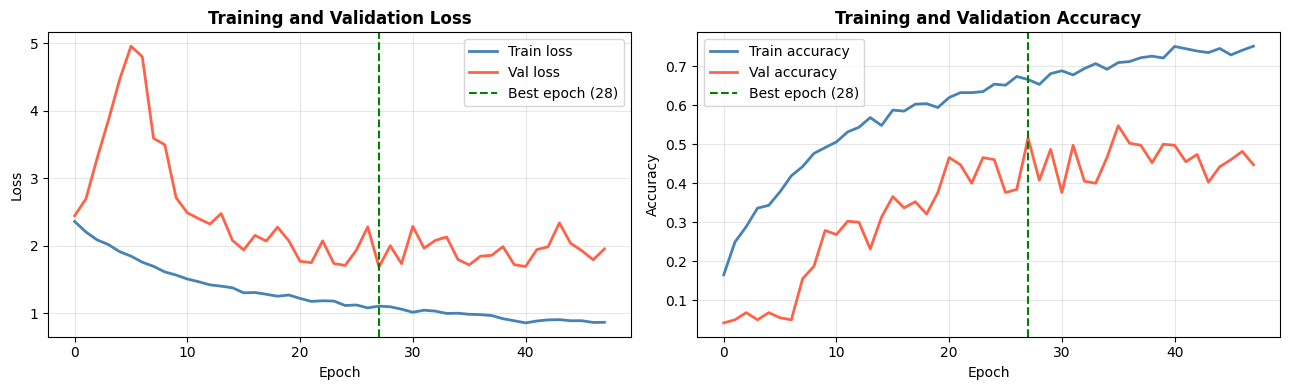

Saved: output_block1\cnn_training_curves.png
Best epoch        : 28
Best val loss     : 1.6831
Best val accuracy : 0.5474


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train loss',     color='steelblue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val loss',       color='tomato',    linewidth=2)
axes[0].set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train accuracy', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val accuracy',   color='tomato',    linewidth=2)
axes[1].set_title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

best_epoch = np.argmin(history.history['val_loss'])
for ax in axes:
    ax.axvline(best_epoch, color='green', linestyle='--', linewidth=1.5,
               label=f'Best epoch ({best_epoch+1})')
    ax.legend()

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'cnn_training_curves.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')
print(f'Best epoch        : {best_epoch + 1}')
print(f'Best val loss     : {min(history.history["val_loss"]):.4f}')
print(f'Best val accuracy : {max(history.history["val_accuracy"]):.4f}')


## 11. File-Level Evaluation — Score Fusion



In [61]:
def predict_file_level(model, X_seg, y_file, file_idx, n_classes=N_CLASSES):
    probs   = model.predict(X_seg, verbose=0)
    n_files = len(y_file)
    y_pred_file = np.zeros(n_files, dtype=np.int32)
    for i in range(n_files):
        mask = file_idx == i
        avg_prob = probs[mask].mean(axis=0)
        y_pred_file[i] = np.argmax(avg_prob)
    return y_pred_file, y_file


y_pred_train, y_true_train = predict_file_level(
    model_cnn, X_train_seg, y_train_file, file_idx_train
)
train_acc_file = accuracy_score(y_true_train, y_pred_train)
print(f'File-level train accuracy (score fusion): {train_acc_file:.4f}')


File-level train accuracy (score fusion): 0.6700


## 12. Evaluate on Official Test Set




In [ ]:
TEST_PATH = r'C:\Users\34610\Desktop\UNIVERSIDAD\Máster\Integracion tecnologias\Proyecto\scenes_stereo_testset'  

test_records = []
for filename in sorted(os.listdir(TEST_PATH)):
    if not filename.endswith('.wav'):
        continue
    label = re.sub(r'\d+$', '', os.path.splitext(filename)[0])
    if label not in CLASS_TO_IDX:
        continue
    test_records.append({
        'filename' : filename,
        'filepath' : os.path.join(TEST_PATH, filename),
        'label'    : label,
        'label_idx': CLASS_TO_IDX[label]
    })

df_test = pd.DataFrame(test_records)
print(f'Test files: {len(df_test)}')

X_test_seg, y_test_seg, y_test_file, file_idx_test = build_segment_dataset(df_test)

# Aplicar la misma normalización del train 
X_test_seg = (X_test_seg - global_mean) / (global_std + 1e-9)

print(f'Test segments: {X_test_seg.shape}')


Test files: 100


Building segment dataset: 100%|██████████| 100/100 [00:06<00:00, 16.58it/s]


Test segments: (1900, 128, 128, 1)


In [63]:
y_pred_test, y_true_test = predict_file_level(
    model_cnn, X_test_seg, y_test_file, file_idx_test
)

test_acc = accuracy_score(y_true_test, y_pred_test)
test_f1  = f1_score(y_true_test, y_pred_test, average='macro')

print('=' * 60)
print('CNN — OFFICIAL TEST SET RESULTS')
print('=' * 60)
print(f'  File-level accuracy : {test_acc:.4f}')
print(f'  File-level F1 macro : {test_f1:.4f}')
print()
print('Comparison with baselines:')
print(f'  E1 Log-Mel + kNN : 0.4000')
print(f'  E2 Log-Mel + SVM : 0.5900')
print(f'  E3 MFCC + kNN    : 0.6000')
print(f'  E4 MFCC + SVM    : 0.7500  <- previous best')
print(f'  CNN (Log-Mel)    : {test_acc:.4f}  <- this model')
print('=' * 60)

improvement = test_acc - 0.75
if improvement > 0:
    print(f'\nImprovement over best baseline: +{improvement:.4f} ({improvement*100:.1f}%)')
else:
    print(f'\nDifference vs best baseline: {improvement:.4f} ({improvement*100:.1f}%)')


CNN — OFFICIAL TEST SET RESULTS
  File-level accuracy : 0.6400
  File-level F1 macro : 0.6501

Comparison with baselines:
  E1 Log-Mel + kNN : 0.4000
  E2 Log-Mel + SVM : 0.5900
  E3 MFCC + kNN    : 0.6000
  E4 MFCC + SVM    : 0.7500  <- previous best
  CNN (Log-Mel)    : 0.6400  <- this model

Difference vs best baseline: -0.1100 (-11.0%)


## 13. Confusion Matrix and Per-Class Analysis


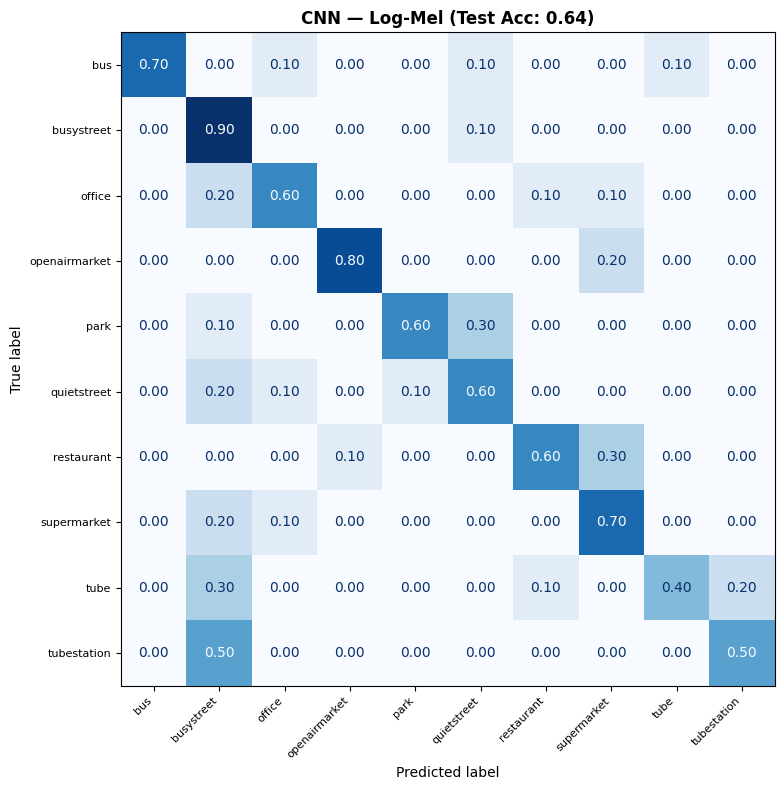

Saved: output_block1\cnn_confusion_matrix.png

Detailed classification report — CNN (Test Set):
               precision    recall  f1-score   support

          bus       1.00      0.70      0.82        10
   busystreet       0.38      0.90      0.53        10
       office       0.67      0.60      0.63        10
openairmarket       0.89      0.80      0.84        10
         park       0.86      0.60      0.71        10
  quietstreet       0.55      0.60      0.57        10
   restaurant       0.75      0.60      0.67        10
  supermarket       0.54      0.70      0.61        10
         tube       0.80      0.40      0.53        10
  tubestation       0.71      0.50      0.59        10

     accuracy                           0.64       100
    macro avg       0.71      0.64      0.65       100
 weighted avg       0.71      0.64      0.65       100



In [64]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_true_test, y_pred_test, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
ax.set_title(f'CNN — Log-Mel (Test Acc: {test_acc:.2f})', fontsize=12, fontweight='bold')
ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(CLASSES, fontsize=8)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'cnn_confusion_matrix.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

print('\nDetailed classification report — CNN (Test Set):')
print(classification_report(y_true_test, y_pred_test, target_names=CLASSES))


## 14. Final Comparison — All Models


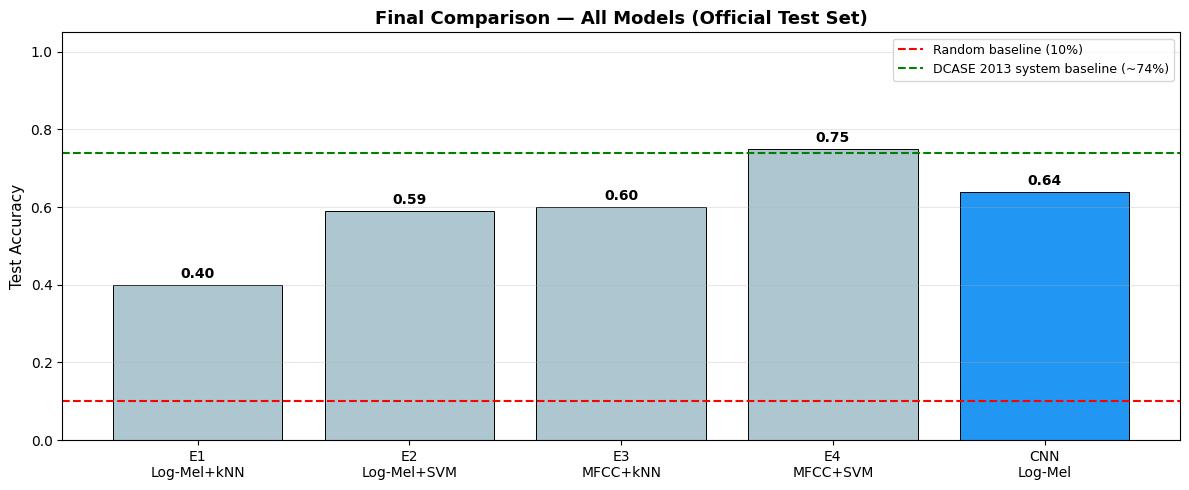

Saved: output_block1\final_comparison_all_models.png


In [65]:
models     = ['E1\nLog-Mel+kNN', 'E2\nLog-Mel+SVM', 'E3\nMFCC+kNN',
              'E4\nMFCC+SVM', 'CNN\nLog-Mel']
test_accs  = [0.40, 0.59, 0.60, 0.75, test_acc]
colors_bar = ['#aec6cf', '#aec6cf', '#aec6cf', '#aec6cf', '#2196F3']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(models, test_accs, color=colors_bar, edgecolor='black', linewidth=0.7)

for bar, val in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0.10, color='red',   linestyle='--', linewidth=1.5, label='Random baseline (10%)')
ax.axhline(0.74, color='green', linestyle='--', linewidth=1.5, label='DCASE 2013 system baseline (~74%)')
ax.set_title('Final Comparison — All Models (Official Test Set)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'final_comparison_all_models.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


## 15. Save CNN Model


In [66]:
model_path = os.path.join(OUTPUT_DIR, 'cnn_asc_model.keras')
model_cnn.save(model_path)
print(f'CNN model saved: {model_path}')

print('\n' + '=' * 60)
print('BLOCK 4 — FINAL SUMMARY')
print('=' * 60)
print(f'Architecture       : 2D CNN, 4 Conv blocks + GAP')
print(f'Input shape        : ({N_FRAMES}, {N_MELS}, 1)')
print(f'Segment duration   : {N_FRAMES * HOP_LEN / SR:.1f}s')
print(f'Segments per file  : ~{len(X_train_seg) // len(df_train)}')
print(f'Total train segs   : {len(X_train_seg)}')
print(f'Epochs trained     : {len(history.history["loss"])}')
print(f'Test accuracy      : {test_acc:.4f}')
print(f'Test F1 macro      : {test_f1:.4f}')
print(f'Best baseline      : 0.7500 (E4 MFCC+SVM)')
print(f'Improvement        : {test_acc - 0.75:+.4f}')
print('=' * 60)


CNN model saved: output_block1\cnn_asc_model.keras

BLOCK 4 — FINAL SUMMARY
Architecture       : 2D CNN, 4 Conv blocks + GAP
Input shape        : (128, 128, 1)
Segment duration   : 3.0s
Segments per file  : ~19
Total train segs   : 1900
Epochs trained     : 48
Test accuracy      : 0.6400
Test F1 macro      : 0.6501
Best baseline      : 0.7500 (E4 MFCC+SVM)
Improvement        : -0.1100
